# SMACNP Training: PeakWeather Context → PeakWeather Targets

This notebook trains an SMACNP model entirely on PeakWeather (PW) station data: PW train-station readings serve as context, and PW val-station readings serve as the training target.

## Setup

| | |
|---|---|
| **Context** | 103 PW train stations — (lon, lat, elev, mTPI, cos_doy, sin_doy) + T_obs |
| **Target (val loss)** | 34 PW val stations |
| **Station split** | 60 / 20 / 20 → 103 train / 34 val / 35 test from 172 valid PW stations (≥ 99% availability, 2017–2024) |
| **Temporal split** | 5-fold cross-validation over 2017–2024 (2921 days) |
| **Temperature** | Daily mean |
| **Normalization** | PW train-station statistics |

## Key design choices

- **Pure PW setup:** Both context and target come from the same dataset, so the model learns to predict unobserved PW stations from the observed ones — a spatial interpolation task across Swiss terrain using the station altitude and mTPI as terrain descriptors.
- **Station holdout:** The test stations are never seen during training (neither as context nor as target), providing an unbiased spatial generalization evaluation.
- **Comparison with MS-target variant:** `training_notebook_MS_PWstations.ipynb` replaces the val-side target with MeteoSwiss reference measurements, which may yield better-calibrated predictions at the cost of requiring an additional dataset.

## Companion notebook

Use **predictions_pw.ipynb** to evaluate the trained model on the PW test stations.


In [16]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [17]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


In [18]:
# Training configuration - modify these parameters as needed
PW_FIRST_DATE        = '2017-01-01'
PW_LAST_DATE         = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

PARAMS = params.Params(
    VARIABLE='tmax',
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='peakweather',
    PW_TRAIN_FRAC=0.8,
    PW_VAL_FRAC=0.0,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=70,
    PATIENCE=30,
    N_FOLDS=5,
    TRIAL_NAME='test-2017-50e-5f-smacnp-pw-mean-v2',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=8,
    SMACNP_HIDDEN=256,
    NUM_LAYERS_MLP=2,
    USE_PE=True,
    PE_DIM=32,
)



print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, TEMPERATURE_TYPE='max', SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=70, BATCH_SIZE=8, LR=0.0005, PATIENCE=30, LOSS_FN='gll', N_FOLDS=5, SEED=42, TRIAL_NAME='test-2017-50e-5f-smacnp-pw-mean-v2', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, ERA5_MEAN_TEMP_GLOB=None, METEO_SWISS_MEAN_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=8, SMACNP_HIDDEN=256, NUM_LAYERS_MLP=2, USE_PE=True, PE_DIM=32, PW_TRAIN_FRAC=0.8, PW_VAL_FRAC=0.0, STATION_SPLIT_SEED=42, CONTEXT_TYPE='peakweather')


In [19]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

In [20]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 1.94 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [21]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmean, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    station_type=None,
    aggregation_method='mean',
)
pw_dates_pd = pd.DatetimeIndex(daily_tmean.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [22]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [23]:
# Split stations 60 / 20 / 20
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

# Compute normalization stats from train stations only
pw_metadata = ds.compute_pw_metadata(daily_tmean, train_stations)
print(f"PW metadata: mean={pw_metadata.data_mean:.2f} K, std={pw_metadata.data_std:.2f} K")


Station split: 137 train / 0 val / 35 test
PW train stats: mean=280.93 K, std=8.07 K
PW metadata: mean=280.93 K, std=8.07 K


In [24]:
# Pool: all train+val stations — random context drawn from here each training step
x_pool, y_pool_raw = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=train_stations, 
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=pw_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
y_pool_raw     = y_pool_raw.unsqueeze(-1)
y_context_pool = torch.nan_to_num(y_pool_raw, nan=0.0)
y_target_pool  = y_pool_raw.squeeze(-1)
print(f"x_pool:         {x_pool.shape}  # (T, 137, 6)")
print(f"y_context_pool: {y_context_pool.shape}  # (T, 137, 1)")
print(f"y_target_pool:  {y_target_pool.shape}  # (T, 137)")



x_pool:         torch.Size([2921, 137, 6])  # (T, 137, 6)
y_context_pool: torch.Size([2921, 137, 1])  # (T, 137, 1)
y_target_pool:  torch.Size([2921, 137])  # (T, 137)


In [25]:
params.set_seed(PARAMS.SEED)

In [26]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [27]:
# Save config and PW metadata for prediction notebooks
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(pw_metadata, OUTPUT_DIR / 'metadata.json')

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)
    model, loss_fn, get_value_fn = model_factory.build_smacnp(PARAMS, x_pool.shape[-1])
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_pool,     
        y_context=y_context_pool,      
        x_target=x_pool,  
        y_target=y_target_pool, 
        context_fraction=(0.2, 0.8),
        exclusive_context=False,
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )


    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(
    os.path.join(OUTPUT_DIR, 'stats.csv'), index=False
)
print(f'\nTraining finished. Models saved in {OUTPUT_DIR}.')



Starting fold 1/5...

Built SMACNP with 1,009,667 trainable parameters
Fold 1/5 | Epoch 0 | train NLL 0.108 | test NLL 0.098 | med MAE 0.128 | elapsed 4s | est. remaining 302s
Fold 1/5 | Epoch 1 | train NLL 0.098 | test NLL 0.104 | med MAE 0.138 | elapsed 9s | est. remaining 299s
Fold 1/5 | Epoch 2 | train NLL 0.094 | test NLL 0.084 | med MAE 0.112 | elapsed 13s | est. remaining 294s
Fold 1/5 | Epoch 3 | train NLL 0.094 | test NLL 0.081 | med MAE 0.109 | elapsed 18s | est. remaining 289s
Fold 1/5 | Epoch 4 | train NLL 0.081 | test NLL 0.066 | med MAE 0.087 | elapsed 22s | est. remaining 284s
Fold 1/5 | Epoch 5 | train NLL 0.071 | test NLL 0.073 | med MAE 0.101 | elapsed 26s | est. remaining 281s
Fold 1/5 | Epoch 6 | train NLL 0.056 | test NLL 0.059 | med MAE 0.080 | elapsed 31s | est. remaining 278s
Fold 1/5 | Epoch 7 | train NLL 0.061 | test NLL 0.070 | med MAE 0.099 | elapsed 35s | est. remaining 273s
Fold 1/5 | Epoch 8 | train NLL 0.055 | test NLL 0.044 | med MAE 0.057 | elapsed 40

In [28]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [29]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.138465,0.988450,0.990066,0,0.102251,0.106423
1,0,0.141404,0.989706,0.991073,1,0.095026,0.106566
2,0,0.101601,0.992409,0.993477,2,0.085995,0.076983
3,0,0.129121,0.994934,0.995637,3,0.072349,0.092152
4,0,0.074002,0.996458,0.997387,4,0.055001,0.054184
...,...,...,...,...,...,...,...
695,4,0.013474,0.999854,0.999824,65,0.033044,0.011397
696,4,0.022548,0.999764,0.999773,66,0.032932,0.017790
697,4,0.020515,0.999748,0.999710,67,0.035659,0.016897
698,4,0.015558,0.999796,0.999782,68,0.031953,0.012774


  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_fold0


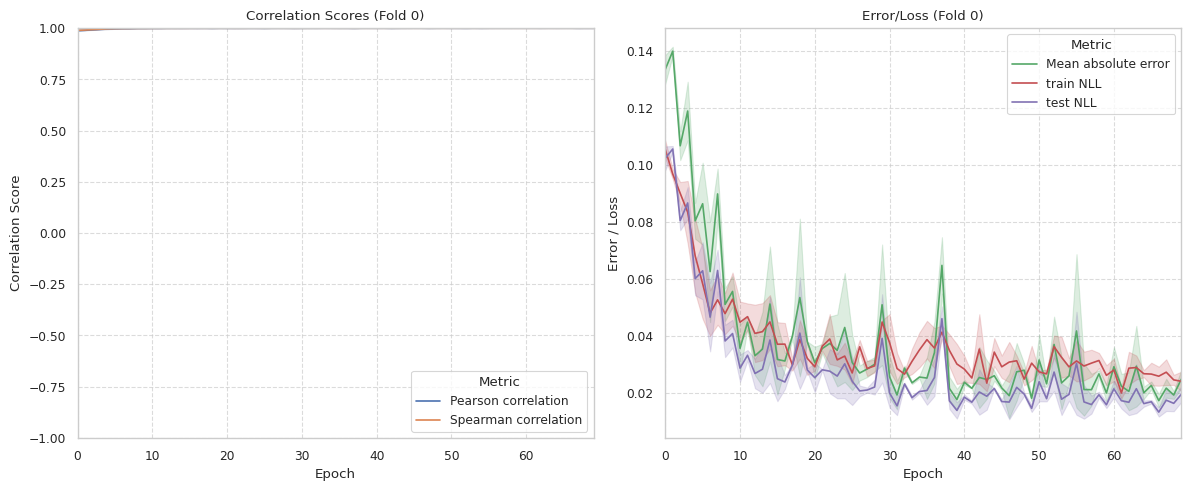

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_fold1


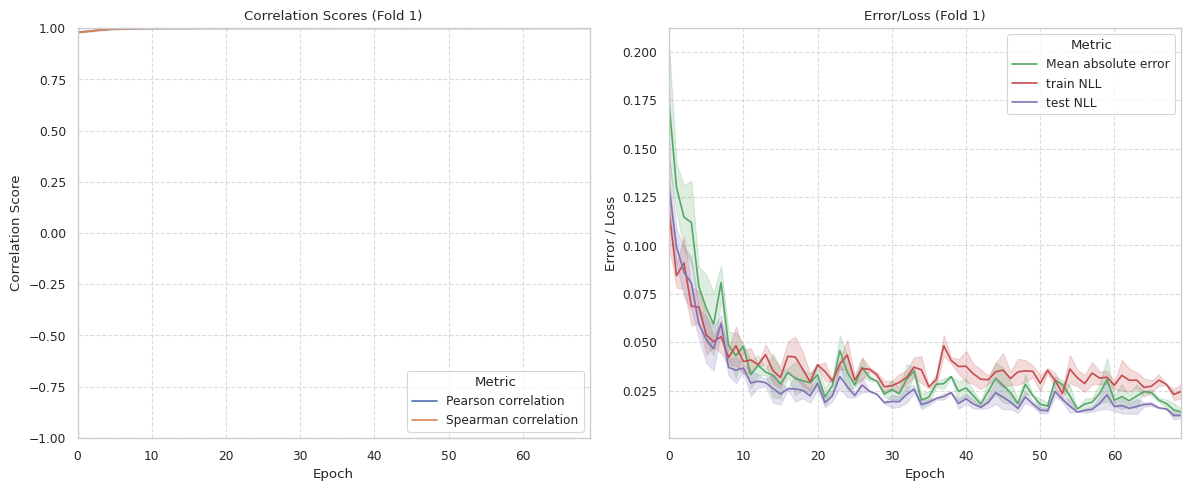

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_fold2


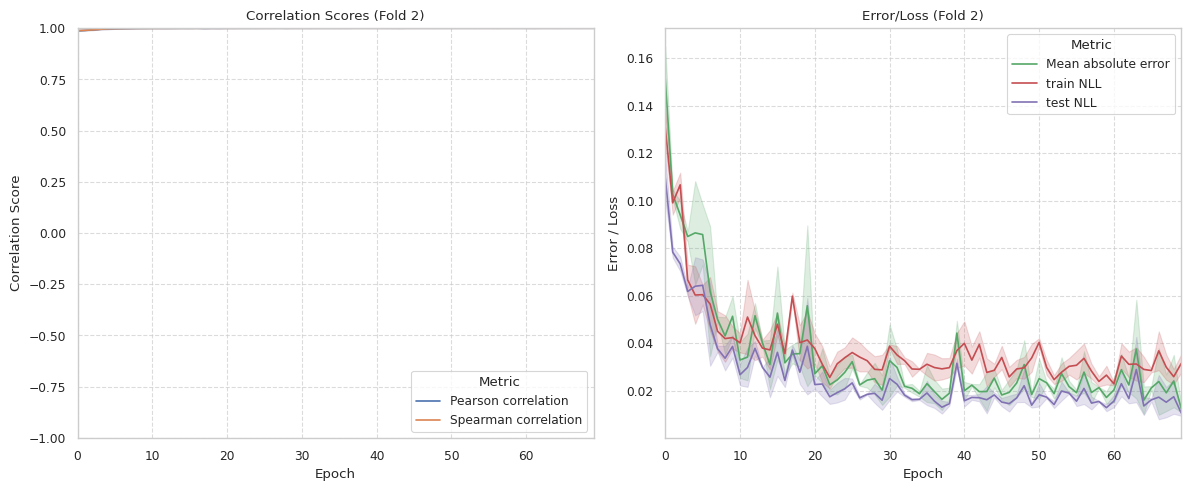

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_fold3


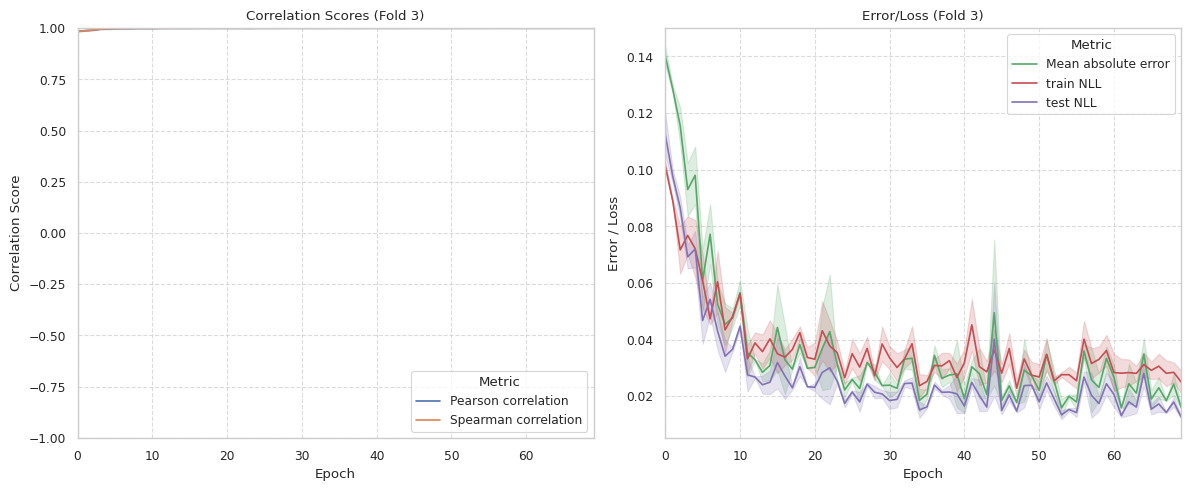

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_fold4


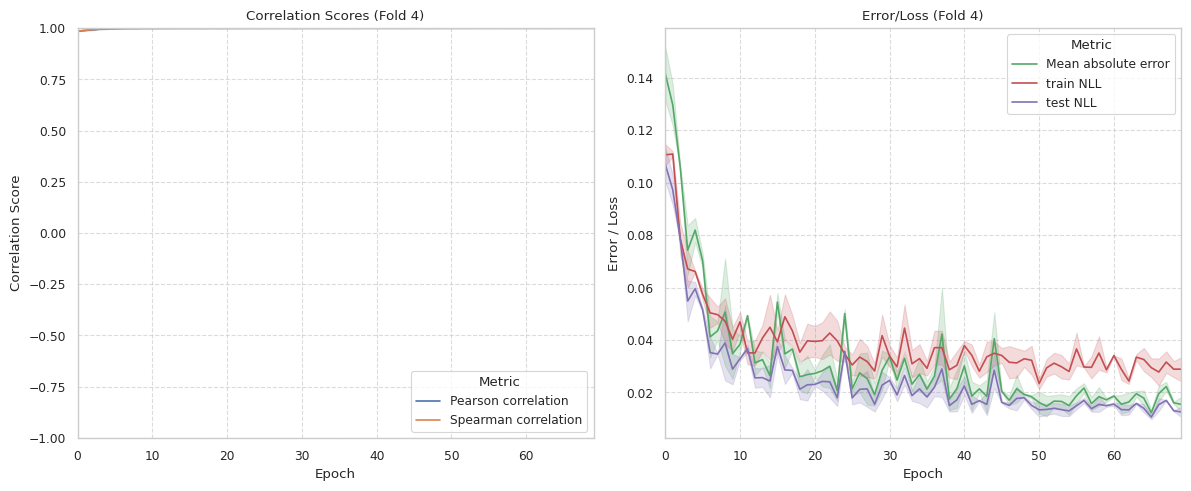

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v2/trainingstats_all


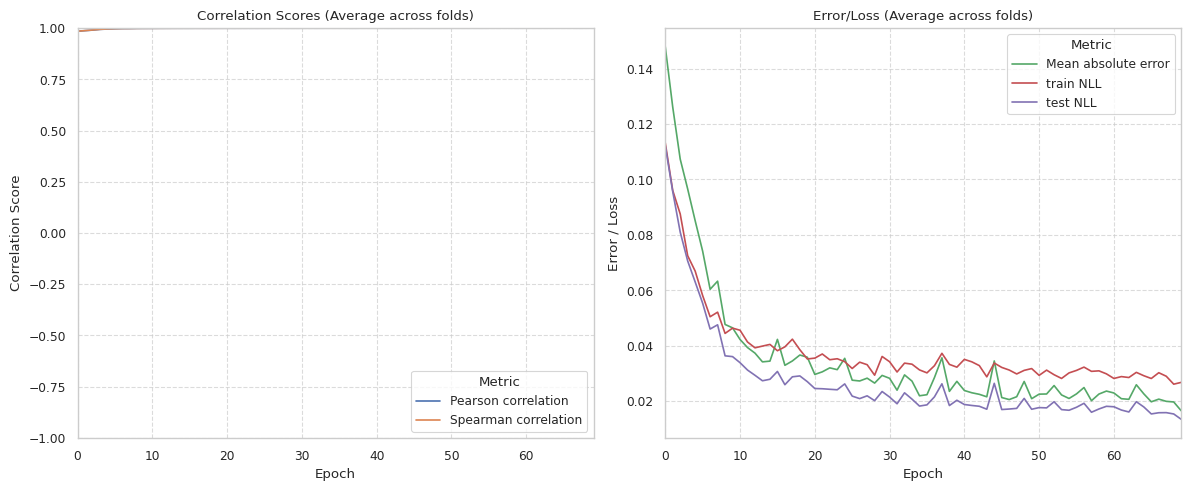

In [30]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()